In [ ]:
include("CRD_STA.jl")
include("LST_BEK.jl")
import .CRD_BF as BF
using Plots
using LinearAlgebra
using ProgressMeter
using NonlinearEigenproblems

In [116]:
N_cheb = 99
Re = 500
R = sqrt(Re)
Ma = 3
Mr = Re*Ma
Tw = 0.8
gamma = 1.4
sigma = 0.72
be = 0.12
omega = 0
F,G,W,f,q,D,D2,x,t,PHI = baseflow_var(N_cheb)
rho,H,T = T_ca(Re,Ma,f,q,W,gamma,Tw,x,t,N_cheb)
lam = -(2/3) * T
kappa = (1/sigma) * T
# A,B = Time_mode(sigma,gamma,Re,Ma,Tw,al,be)

100×1 Matrix{Float64}:
     1.1111111111111107
   324.46564679999085
  1290.8794975285805
  2889.432957039249
  5102.027155685423
  7903.542372909971
 11262.074400305226
 15139.244334845394
 19490.536946497563
 24265.747080150053
     ⋮
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821
    -4.591713477751821

In [117]:
A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
nep = PEP([A0,A1,A2]); 
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = iar(nep2,σ=0.05,neigs=50,maxit=500);
λ_orig = sc*λ1

50-element Vector{ComplexF64}:
   0.49609422912500434 + 0.03303059105142073im
    0.5676139806291629 + 0.0070473732241066985im
   0.41564809070407316 + 0.03769892078056072im
    0.4023458230262328 + 0.01038071467236576im
   0.37904627435355664 + 0.23183594406181823im
    0.6131887253402074 + 0.02248193166187094im
     0.352540170783177 + 0.06797145796088629im
    0.7062104291039542 + 0.04085108523865072im
   0.30763891044247493 + 0.04610681277077709im
   0.15441857471712678 + 0.023628618027527838im
                       ⋮
     1.463457990437561 + 0.08460124497941157im
     2.108660570542209 + 0.2120320381433388im
     2.426502807435533 + 0.2734481697954735im
   0.05639194005634278 - 0.09095038407381426im
  -0.17303738969767113 - 0.7463075136768953im
   0.38086271106401726 + 0.4027814056679086im
    0.2674444388595333 + 0.2865137548376627im
     2.803674323679738 + 0.3505996021068097im
 -0.005995943934744424 - 0.3039604994775793im

In [ ]:
# phi_hat = [u,v,w,rho,p,t]

A11 = ((im * al * R + 1) .* rho) .* I(N_cheb + 1)
A12 = (im * be * R).*rho .* I(N_cheb + 1)
A13 = R * rho .*(D*rho.* I(N_cheb + 1) + rho .* D)
A14 = (im * R .* (al * F + be * G)) .* I(N_cheb + 1)  + 2 * F .* I(N_cheb + 1)  + rho .* (D * H) .* I(N_cheb + 1) + rho .* H .* D 
A15 = zeros(N_cheb + 1, N_cheb + 1)
A16 = zeros(N_cheb + 1, N_cheb + 1)

A21 = im * R * rho .* (al *  F + be * G) .* I(N_cheb + 1) + rho .* F .* I(N_cheb + 1) + al^2 .* (lam + 2  * T) .* I(N_cheb + 1) + be^2 * T .* I(N_cheb + 1) + rho.^2 .* H .* D - rho .* D^2
A22 = -2 * rho .* (G .+ 1) .* I(N_cheb + 1) + al * be * (lam .+ T) .* I(N_cheb + 1)
A23 = R * rho.^2 .* (D*F) .* I(N_cheb + 1) - im * al *(rho .* (D*T) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D)
A24 = rho .* (D^2 * F) .* I(N_cheb + 1)
A25 = im * al * R .* I(N_cheb + 1)
A26 = -rho .* D * (rho .* (D*F)) .* I(N_cheb + 1) - rho.^2 .* (D*F) .* D

A31 = 2 * rho .* (G .+ 1) .* I(N_cheb + 1) + al * be * (lam .+ T) .* I(N_cheb + 1)
A32 = im * R * rho .* (al *  F + be * G) .* I(N_cheb + 1) + rho .* F .* I(N_cheb + 1) + be^2 * (lam + 2 * T) .* I(N_cheb + 1) + al^2 * T .* I(N_cheb + 1) + rho.^2 .* H .* D - rho .* D^2
A33 = -im * be * (rho .* (D*T) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D) + R * rho.^2 .* (D*G) .* I(N_cheb + 1)
A34 = 2 * F .* (G .+ 1) .* I(N_cheb + 1) + rho .* H .* (D*G) .* I(N_cheb + 1)
A35 = im * be * R .* I(N_cheb + 1)
A36 = -rho .* D * (rho .* (D*G)) .* I(N_cheb + 1) - rho.^2 .* (D*G) .* D

A41 = -im * al *(rho .* (D*lam).* I(N_cheb + 1) + (1 .+ lam .* rho).*D)
A42 = -im * be * (rho .* (D*lam) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D)
A43 = im * R * rho .* (al * F + be * G) .* I(N_cheb + 1) + rho.^2 .* (D * H .* I(N_cheb + 1) + H .* D) 
    - rho .* (2 .+ lam .* rho) .* D^2 + (al^2 + be^2) .* T .* I(N_cheb + 1)
A44 = zeros(N_cheb + 1, N_cheb + 1)
A45 = R * rho .* D 
A46 = - im * rho .* D * (al * F + be * G) .* I(N_cheb + 1)

A51 = -2 * (gamma - 1) * Ma^2 * rho .* (D*F) .* D 
A52 = -2 * (gamma - 1) * Ma^2 * rho .* (D*G) .* D
A53 = -2 * im * (gamma - 1) * Ma^2 * D * (al * F + be * G) .* I(N_cheb + 1) + R * rho.^2 .* D * T .* I(N_cheb + 1)
A54 = rho .* H .* (D * T) .* I(N_cheb + 1)
A55 = -(gamma - 1) * Ma^2 .* (im * R * (al * F + be * G) .* I(N_cheb + 1) + rho .* H .* D)
A56 = im * R * rho .* (al * F + be * G) .* I(N_cheb + 1) + (al^2 + be^2) * kappa .* I(N_cheb + 1) + rho.^2 .* (H .* D - kappa .* D^2)
    + (1/sigma) * (-rho .* ((D*rho .* D*T + rho .* D^2 * T ).* I(N_cheb + 1) - (rho .* (D * T) .* D)))
    + (-(gamma - 1) * Ma^2 * rho.^2 .* ((D * F).^2 + (D * G).^2 )).* I(N_cheb + 1)

A61 = zeros(N_cheb + 1, N_cheb + 1)
A62 = zeros(N_cheb + 1, N_cheb + 1)
A63 = zeros(N_cheb + 1, N_cheb + 1)
A64 = - T .* I(N_cheb + 1)
A65 = gamma * Ma^2 .* I(N_cheb + 1)
A66 = -rho .* I(N_cheb + 1)

A = [A11 A12 A13 A14 A15 A16; A21 A22 A23 A24 A25 A26; A31 A32 A33 A34 A35 A36; A41 A42 A43 A44 A45 A46; A51 A52 A53 A54 A55 A56; A61 A62 A63 A64 A65 A66]

B11 = zeros(N_cheb + 1, N_cheb + 1)
B12 = zeros(N_cheb + 1, N_cheb + 1)
B13 = zeros(N_cheb + 1, N_cheb + 1)
B14 = im * R .* I(N_cheb + 1)
B15 = zeros(N_cheb + 1, N_cheb + 1)
B16 = zeros(N_cheb + 1, N_cheb + 1)

B21 = im * R * rho .* I(N_cheb + 1)
B22 = zeros(N_cheb + 1, N_cheb + 1)
B23 = zeros(N_cheb + 1, N_cheb + 1)
B24 = zeros(N_cheb + 1, N_cheb + 1)
B25 = zeros(N_cheb + 1, N_cheb + 1)
B26 = zeros(N_cheb + 1, N_cheb + 1)

B31 = zeros(N_cheb + 1, N_cheb + 1)
B32 = im * R * rho .* I(N_cheb + 1)
B33 = zeros(N_cheb + 1, N_cheb + 1)
B34 = zeros(N_cheb + 1, N_cheb + 1)
B35 = zeros(N_cheb + 1, N_cheb + 1)
B36 = zeros(N_cheb + 1, N_cheb + 1)

B41 = zeros(N_cheb + 1, N_cheb + 1)
B42 = zeros(N_cheb + 1, N_cheb + 1)
B43 = im * R * rho .* I(N_cheb + 1)
B44 = zeros(N_cheb + 1, N_cheb + 1)
B45 = zeros(N_cheb + 1, N_cheb + 1)
B46 = zeros(N_cheb + 1, N_cheb + 1)

B51 = zeros(N_cheb + 1, N_cheb + 1)
B52 = zeros(N_cheb + 1, N_cheb + 1)
B53 = zeros(N_cheb + 1, N_cheb + 1)
B54 = zeros(N_cheb + 1, N_cheb + 1)
B55 = -(gamma-1) * Ma^2 * im * R  .* I(N_cheb + 1)
B56 = im * R * rho .* I(N_cheb + 1)

B61 = zeros(N_cheb + 1, N_cheb + 1)
B62 = zeros(N_cheb + 1, N_cheb + 1)
B63 = zeros(N_cheb + 1, N_cheb + 1)
B64 = zeros(N_cheb + 1, N_cheb + 1)
B65 = zeros(N_cheb + 1, N_cheb + 1)
B66 = zeros(N_cheb + 1, N_cheb + 1)

B = [B11 B12 B13 B14 B15 B16; B21 B22 B23 B24 B25 B26; B31 B32 B33 B34 B35 B36; B41 B42 B43 B44 B45 B46; B51 B52 B53 B54 B55 B56; B61 B62 B63 B64 B65 B66]

A = A[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6))]
B = B[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6))]


In [ ]:
# (A0 +A1*alpha +A2*alpha^2)ϕ=0 
# phi_hat = [u,v,w,rho,p,t]
A0_11 = rho .* I(N_cheb + 1)
A0_12 = im * be * R * rho .* I(N_cheb + 1)
A0_13 = R * rho .* (D*rho .* I(N_cheb + 1) + rho .* D)
A0_14 = im * R * (be * G .- omega ) .* I(N_cheb + 1)  + 2 * F .* I(N_cheb + 1)  + rho .* (D * H) .* I(N_cheb + 1) + rho .* H .* D 
A0_15 = zeros(N_cheb + 1, N_cheb + 1)
A0_16 = zeros(N_cheb + 1, N_cheb + 1)

A0_21 = im * R * rho .* (be * G .- omega ) .* I(N_cheb + 1) + rho .* F .* I(N_cheb + 1) + be^2 * T .* I(N_cheb + 1) + rho.^2 .* H .* D - rho .* D^2
A0_22 = -2 * rho .* (G .+ 1) .* I(N_cheb + 1)
A0_23 = R * rho.^2 .* D*F .* I(N_cheb + 1)
A0_24 = rho .* (D^2 * F) .* I(N_cheb + 1)
A0_25 = zeros(N_cheb + 1, N_cheb + 1)
A0_26 = -rho .* (D * (rho .* (D * F))) .* I(N_cheb + 1) - rho.^2 .* (D*F) .* D

A0_41 = zeros(N_cheb + 1, N_cheb + 1)
A0_42 = -im * be * (rho .* (D*lam) + (1 .+ lam .* rho)).*D
A0_43 = im * R * rho .* (be * G .- omega) .* I(N_cheb + 1) + rho.^2 .* ((D*H) .* I(N_cheb + 1) + H .* D) - rho .* (2 .+ lam .* rho) .* D^2 + be^2 * T .* I(N_cheb + 1)
A0_44 = zeros(N_cheb + 1, N_cheb + 1)
A0_45 = R * rho .* D
A0_46 = -im * rho .* (be .* (D*G)) .* I(N_cheb + 1)

A0_31 = 2 * rho .* (G .+ 1) .* I(N_cheb + 1)
A0_32 = im * R * rho .* (be * G .- omega) .* I(N_cheb + 1) + rho .* F .* I(N_cheb + 1) + be^2 * (lam + 2 * T) .* I(N_cheb + 1) + rho.^2 .* H .* D - rho .* D^2
A0_33 = R * rho.^2  .* (D*G) .* I(N_cheb + 1) - im * be * (rho .* (D*lam) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D)
A0_34 = 2 * F .* (G .+ 1) .* I(N_cheb + 1) + rho .* H .* (D*G) .* I(N_cheb + 1)
A0_35 = im * be * R .* I(N_cheb + 1)
A0_36 = -rho .* (D * (rho .* (D * G))) .* I(N_cheb + 1) - rho.^2 .* (D*G) .* D

A0_51 = -2 * (gamma - 1) * Ma^2 * rho .* (D*F) .* D
A0_52 = -2 * (gamma - 1) * Ma^2 * rho .* (D*G) .* D
A0_53 = -2 * im * (gamma - 1) * Ma^2 * (be * (D*G))  .* I(N_cheb + 1 ) + R * rho.^2 .* (D*T) .* I(N_cheb + 1)
A0_54 = rho .* H .* (D*T) .* I(N_cheb + 1)
A0_55 = -(gamma - 1) * Ma^2 * (im * R * (be * G .- omega) .* I(N_cheb + 1) + rho .* H .* D)
A0_56 = im * R * rho .* (be * G .- omega) .* I(N_cheb + 1)+ be^2 * kappa .* I(N_cheb + 1) + rho.^2 .* (H .* D - kappa .* D^2) + (1/sigma) * (-rho .* ((D*rho) .* T .* I(N_cheb + 1) + rho .* (D^2 * T) .* I(N_cheb + 1) - rho .* (D*T) .* D))
    + (-(gamma - 1) * Ma^2 * rho.^2 .* ((D*F).^2 + (D*G).^2) .* I(N_cheb + 1))

A0_61 = zeros(N_cheb + 1, N_cheb + 1)
A0_62 = zeros(N_cheb + 1, N_cheb + 1)
A0_63 = zeros(N_cheb + 1, N_cheb + 1)
A0_64 = -T .* I(N_cheb + 1)
A0_65 = gamma * Ma^2 .* I(N_cheb + 1)
A0_66 = -rho .* I(N_cheb + 1)

A1_11 = im * R * rho .* I(N_cheb + 1)
A1_12 = zeros(N_cheb + 1, N_cheb + 1)
A1_13 = zeros(N_cheb + 1, N_cheb + 1)
A1_14 = im * R * F .* I(N_cheb + 1)
A1_15 = zeros(N_cheb + 1, N_cheb + 1)
A1_16 = zeros(N_cheb + 1, N_cheb + 1)

A1_21 = im * R * rho .* F .* I(N_cheb + 1)
A1_22 = be * (lam .+ T) .* I(N_cheb + 1)
A1_23 = -im * ((rho .* (D*T) + (1 .+ lam .* rho)).* D)
A1_24 = zeros(N_cheb + 1, N_cheb + 1)
A1_25 = im * R .* I(N_cheb + 1)
A1_26 = zeros(N_cheb + 1, N_cheb + 1)

A1_31 = be * (lam + T) .* I(N_cheb + 1)
A1_32 = im * R * rho .* F .* I(N_cheb + 1)
A1_33 = zeros(N_cheb + 1, N_cheb + 1)
A1_34 = zeros(N_cheb + 1, N_cheb + 1)
A1_35 = zeros(N_cheb + 1, N_cheb + 1)
A1_36 = zeros(N_cheb + 1, N_cheb + 1)

A1_41 = -im * (rho .* (D*lam) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D)
A1_42 = zeros(N_cheb + 1, N_cheb + 1)
A1_43 = im * R * rho .* F .* I(N_cheb + 1)
A1_44 = zeros(N_cheb + 1, N_cheb + 1)
A1_45 = zeros(N_cheb + 1, N_cheb + 1)
A1_46 = zeros(N_cheb + 1, N_cheb + 1)

A1_51 = zeros(N_cheb + 1, N_cheb + 1)
A1_52 = zeros(N_cheb + 1, N_cheb + 1)
A1_53 = zeros(N_cheb + 1, N_cheb + 1)
A1_54 = zeros(N_cheb + 1, N_cheb + 1)
A1_55 = -(gamma - 1) * Ma^2 * im * R * F .* I(N_cheb + 1)
A1_56 = im * R * rho .* F .* I(N_cheb + 1)

A1_61 = zeros(N_cheb + 1, N_cheb + 1)
A1_62 = zeros(N_cheb + 1, N_cheb + 1)
A1_63 = zeros(N_cheb + 1, N_cheb + 1)
A1_64 = zeros(N_cheb + 1, N_cheb + 1)
A1_65 = zeros(N_cheb + 1, N_cheb + 1)
A1_66 = zeros(N_cheb + 1, N_cheb + 1)

A2_11 = zeros(N_cheb + 1, N_cheb + 1)
A2_12 = zeros(N_cheb + 1, N_cheb + 1)
A2_13 = zeros(N_cheb + 1, N_cheb + 1)
A2_14 = zeros(N_cheb + 1, N_cheb + 1)
A2_15 = zeros(N_cheb + 1, N_cheb + 1)
A2_16 = zeros(N_cheb + 1, N_cheb + 1)

A2_21 = (lam + 2 * T) .* I(N_cheb + 1)
A2_22 = zeros(N_cheb + 1, N_cheb + 1)
A2_23 = zeros(N_cheb + 1, N_cheb + 1)
A2_24 = zeros(N_cheb + 1, N_cheb + 1)
A2_25 = zeros(N_cheb + 1, N_cheb + 1)
A2_26 = zeros(N_cheb + 1, N_cheb + 1)

A2_31 = zeros(N_cheb + 1, N_cheb + 1)
A2_32 = T .* I(N_cheb + 1)
A2_33 = zeros(N_cheb + 1, N_cheb + 1)
A2_34 = zeros(N_cheb + 1, N_cheb + 1)
A2_35 = zeros(N_cheb + 1, N_cheb + 1)
A2_36 = zeros(N_cheb + 1, N_cheb + 1)

A2_41 = zeros(N_cheb + 1, N_cheb + 1)
A2_42 = zeros(N_cheb + 1, N_cheb + 1)
A2_43 = T .* I(N_cheb + 1)
A2_44 = zeros(N_cheb + 1, N_cheb + 1)
A2_45 = zeros(N_cheb + 1, N_cheb + 1)
A2_46 = zeros(N_cheb + 1, N_cheb + 1)

A2_51 = zeros(N_cheb + 1, N_cheb + 1)
A2_52 = zeros(N_cheb + 1, N_cheb + 1)
A2_53 = zeros(N_cheb + 1, N_cheb + 1)
A2_54 = zeros(N_cheb + 1, N_cheb + 1)
A2_55 = zeros(N_cheb + 1, N_cheb + 1)
A2_56 = kappa .* I(N_cheb + 1)

A2_61 = zeros(N_cheb + 1, N_cheb + 1)
A2_62 = zeros(N_cheb + 1, N_cheb + 1)
A2_63 = zeros(N_cheb + 1, N_cheb + 1)
A2_64 = zeros(N_cheb + 1, N_cheb + 1)
A2_65 = zeros(N_cheb + 1, N_cheb + 1)
A2_66 = zeros(N_cheb + 1, N_cheb + 1) 

A0 = [A0_11 A0_12 A0_13 A0_14 A0_15 A0_16 ; A0_21 A0_22 A0_23 A0_24 A0_25 A0_26 ; A0_31 A0_32 A0_33 A0_34 A0_35 A0_36 ; A0_41 A0_42 A0_43 A0_44 A0_45 A0_46 ; A0_51 A0_52 A0_53 A0_54 A0_55 A0_56 ; A0_61 A0_62 A0_63 A0_64 A0_65 A0_66]
A1 = [A1_11 A1_12 A1_13 A1_14 A1_15 A1_16 ; A1_21 A1_22 A1_23 A1_24 A1_25 A1_26 ; A1_31 A1_32 A1_33 A1_34 A1_35 A1_36 ; A1_41 A1_42 A1_43 A1_44 A1_45 A1_46 ; A1_51 A1_52 A1_53 A1_54 A1_55 A1_56 ; A1_61 A1_62 A1_63 A1_64 A1_65 A1_66]
A2 = [A2_11 A2_12 A2_13 A2_14 A2_15 A2_16 ; A2_21 A2_22 A2_23 A2_24 A2_25 A2_26 ; A2_31 A2_32 A2_33 A2_34 A2_35 A2_36 ; A2_41 A2_42 A2_43 A2_44 A2_45 A2_46 ; A2_51 A2_52 A2_53 A2_54 A2_55 A2_56 ; A2_61 A2_62 A2_63 A2_64 A2_65 A2_66]

A0 = A0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6))]
A1 = A1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6))]
A2 = A2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,5N_cheb + 5,5N_cheb + 6,6N_cheb + 6))]

In [ ]:
function select(values)
    index=findall(x->x==values,λ_orig)
    vec = v1[:,index]
    u = vec[1:N_cheb - 1,1]
    return u
end

In [109]:
u = select(1.049803797260217 - 0.023806089868311342im)

98-element Vector{ComplexF64}:
   -0.000628448730145982 - 0.0014125850143237976im
  -0.0014135576211539262 + 0.0007494592809500507im
 -0.00017345870586193138 + 0.00012640094695407498im
   -4.700983518260788e-5 - 0.00014323064044996573im
   1.6378322422849373e-5 + 6.175807040035014e-5im
  -1.0218866315977232e-5 - 5.265701068708115e-5im
     8.11197464318988e-6 + 4.9943342451716906e-5im
   -6.693955755842063e-6 - 4.896607440453718e-5im
    5.812639976282089e-6 + 4.837061337513846e-5im
   -5.099552279575998e-6 - 4.7914653470634865e-5im
                         ⋮
   -2.580756644521147e-5 + 5.086023319907638e-5im
    1.727794840170031e-5 - 3.655951342386398e-5im
    -9.13509079602416e-6 + 2.03691354221809e-5im
    4.659090030894884e-6 - 1.0982074786778245e-5im
   -1.993685752234342e-6 + 4.952080350856778e-6im
    7.349272307790612e-7 - 1.9210579807293845e-6im
  -2.0763621512147845e-7 + 5.692154775512503e-7im
   3.7378836236858894e-8 - 1.0664084256445718e-7im
  -2.1915779302026978e-9 + 6.425

In [118]:
point = filter(x->-0.1<imag(x)<0.01 , λ_orig)

3-element Vector{ComplexF64}:
  0.5676139806291629 + 0.0070473732241066985im
  1.0635730936650574 - 0.07045109733751279im
 0.05639194005634278 - 0.09095038407381426im

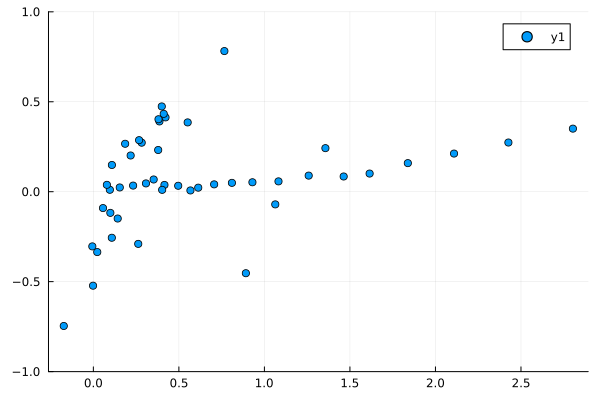

In [120]:
scatter(real(λ_orig),imag(λ_orig),ylims=[-1,1])